#  Efficiency Analysis for the final notebook
**created by: Esraa Nematalla**

This notebook measures how efficient each model is on **CPU**, that is the deployment target.

All numbers come from the main notebook run (same seed, same models):

| Model | Dataset | Acc % | Lat (ms) | Size (MB) |
|---|---|---|---|---|
| TF-IDF + LR | SST-2 | 81.65 | 0.92 ± 0.03 | 2.33 |
| TF-IDF + LR | IMDb | 89.50 | 1.34 ± 0.25 | 2.24 |
| BiLSTM+GloVe+Attn | SST-2 | 85.32 | 2.61 ± 0.15 | 13.86 |
| BiLSTM+GloVe+Attn | IMDb | 88.44 | 7.71 ± 1.07 | 13.86 |
| DistilBERT FP32 | SST-2 | 90.71 | 49.94 ± 4.12 | 255.5 |
| DistilBERT FP32 | IMDb | 91.07 | 99.25 ± 8.42 | 255.5 |
| DistilBERT INT8 | SST-2 | 89.45 | 17.83 ± 1.40 | 132.3 |
| DistilBERT INT8 | IMDb | 89.91 | 49.89 ± 5.92 | 132.3 |

### Sections
1. Setup
2. Accuracy before vs. after quantization
3. Latency benchmarks, mean, std, p95
4. Memory profiling (psutil RSS + tracemalloc)
5. Model size reduction
6. BiLSTM efficiency comparison
7. Pareto frontier: accuracy vs. latency
8. Report-ready overview figure
9. Summary table

## Imports and setup

In [37]:
import os,time,json, pickle, copy, tracemalloc
import numpy as np
import pandas as pd
import psutil
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import accuracy_score, f1_score
from transformers import AutoTokenizer, AutoModelForSequenceClassification

BASE= '/content/project_final'
FIG = f'{BASE}/figures'
RES= f'{BASE}/results'
os.makedirs(FIG,exist_ok=True)
os.makedirs(RES,exist_ok=True)
N_WARMUP =10
N_TIMING= 100
CPU =torch.device('cpu')
MODEL_CKPT='distilbert-base-uncased'
SST2_MAX_LEN=64
IMDB_MAX_LEN =256
print('Ready.')
print(f'CPU cores:{psutil.cpu_count(logical=False)} physical / {psutil.cpu_count()} logical')
print(f'RAM :{psutil.virtual_memory().total / 1e9:.1f} GB')

Ready.
CPU cores:1 physical / 2 logical
RAM :13.6 GB


## Load results

We try to load `all_results.json` written by the main notebook.
If it's not there (e.g. standalone run), we fall back to the hardcoded numbers
recorded from the actual run, so plots always work.

In [38]:
results_path= f'{RES}/all_results.json'
if os.path.exists(results_path):
    with open(results_path) as f:
        RESULTS=json.load(f)
    print(f'Loaded from {results_path} ({len(RESULTS)} entries)')
else:
    RESULTS={
        'logreg_sst2':{'acc': 0.8165, 'f1':0.8158, 'lat_mean_ms': 0.918, 'lat_std_ms': 0.026, 'size_mb': 2.33},
        'logreg_imdb':{'acc': 0.8950, 'f1':0.8950, 'lat_mean_ms': 1.344, 'lat_std_ms': 0.251,'size_mb': 2.24},
        'bilstm_sst2':{'acc': 0.8532, 'f1': 0.8530, 'lat_mean_ms': 2.612, 'lat_std_ms': 0.154, 'size_mb': 13.86},
        'bilstm_imdb':{'acc': 0.8844, 'f1':0.8844, 'lat_mean_ms': 7.710,'lat_std_ms': 1.070, 'size_mb': 13.86},
        'bert_fp32_sst2':{'acc': 0.9071, 'f1':0.9070, 'lat_mean_ms': 49.94,'lat_std_ms': 4.12,  'size_mb': 255.5},
        'bert_fp32_imdb':{'acc': 0.9107, 'f1':0.9107, 'lat_mean_ms': 99.25, 'lat_std_ms': 8.42,  'size_mb': 255.5},
        'bert_int8_sst2':{'acc': 0.8945, 'f1':0.8941, 'lat_mean_ms': 17.83, 'lat_std_ms': 1.40,  'size_mb':132.3},
        'bert_int8_imdb':{'acc': 0.8991, 'f1':0.8990,'lat_mean_ms': 49.89,'lat_std_ms': 5.92,  'size_mb': 132.3},}
    print('Using hardcoded results from the run (no all_results.json found).')
def p95(key): return RESULTS[key]['lat_mean_ms']+1.645 *RESULTS[key]['lat_std_ms']
print('Keys:',list(RESULTS.keys()))

Using hardcoded results from the run (no all_results.json found).
Keys: ['logreg_sst2', 'logreg_imdb', 'bilstm_sst2', 'bilstm_imdb', 'bert_fp32_sst2', 'bert_fp32_imdb', 'bert_int8_sst2', 'bert_int8_imdb']


## Accuracy before vs. after INT8 quantization

Dynamic INT8 quantization (PyTorch `quantize_dynamic`) converts `nn.Linear` weights
to 8-bit integers at load time.

we try to find out how much accuracy do we trade for the speed gain

In [39]:
drop_s2=(RESULTS['bert_fp32_sst2']['acc'] -RESULTS['bert_int8_sst2']['acc']) * 100
drop_im=(RESULTS['bert_fp32_imdb']['acc'] - RESULTS['bert_int8_imdb']['acc']) *100

print('Accuracy before vs. after INT8 quantization')
print(f' SST-2 FP32={RESULTS["bert_fp32_sst2"]["acc"]*100:.2f}% INT8={RESULTS["bert_int8_sst2"]["acc"]*100:.2f}% drop={drop_s2:.2f} pp')
print(f'IMDb FP32={RESULTS["bert_fp32_imdb"]["acc"]*100:.2f}% INT8={RESULTS["bert_int8_imdb"]["acc"]*100:.2f}% drop={drop_im:.2f} pp')

Accuracy before vs. after INT8 quantization
 SST-2 FP32=90.71% INT8=89.45% drop=1.26 pp
IMDb FP32=91.07% INT8=89.91% drop=1.16 pp


### Accuracy Before vs After INT8 Quantization: SST-2

In [40]:
sst2_labels=['TF-IDF+LR', 'BiLSTM', 'BERT FP32', 'BERT INT8']
sst2_means =[RESULTS['logreg_sst2']['lat_mean_ms'], RESULTS['bilstm_sst2']['lat_mean_ms'],
               RESULTS['bert_fp32_sst2']['lat_mean_ms'], RESULTS['bert_int8_sst2']['lat_mean_ms']]
sst2_p95s= [p95('logreg_sst2'), p95('bilstm_sst2'), p95('bert_fp32_sst2'), p95('bert_int8_sst2')]
sst2_stds=[RESULTS['logreg_sst2']['lat_std_ms'],RESULTS['bilstm_sst2']['lat_std_ms'],
               RESULTS['bert_fp32_sst2']['lat_std_ms'],RESULTS['bert_int8_sst2']['lat_std_ms']]
pal4 =['#2ECC71','#9B59B6','#3498DB','#E67E22']
x= np.arange(len(sst2_labels)); w=0.35
live_raw={}
print('Latency data prepared for SST-2.')

Latency data prepared for SST-2.


##  Memory profiling (psutil RSS)

`psutil` reads the **Resident Set Size** : physical RAM the process is using.
We snapshot RSS before and after a forward pass.

These numbers are live when models are loaded from the main notebook.
If run standalone, the cell prints expected footprint ranges based on model disk sizes.

In [41]:
def measure_rss(): return psutil.Process().memory_info().rss /1024**2
def profile_memory(model, tokenizer_obj, max_len, text):
    """Returns (rss_delta_mb, tracemalloc_peak_mb)."""
    model.eval()
    enc=tokenizer_obj([text], max_length=max_len, padding=True,
                        truncation=True, return_tensors='pt')
    ids, mask=enc['input_ids'],enc['attention_mask']
    rss_before =measure_rss()
    tracemalloc.start()
    with torch.no_grad(): model(ids, mask)
    _, peak_bytes =tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return measure_rss() -rss_before, peak_bytes / 1024**2
models_in_mem =('bert_sst2' in dir() and 'q_bert_sst2' in dir())
if models_in_mem:
    tok=AutoTokenizer.from_pretrained(MODEL_CKPT)
    sample='This film was beautifully acted and genuinely moving'
    print('Live RSS profiling:')
    mem_live={}
    for name,model,max_len in [
        ('DistilBERT FP32 / SST-2',bert_sst2,SST2_MAX_LEN),
        ('DistilBERT INT8 / SST-2',q_bert_sst2,SST2_MAX_LEN),
    ]:
        rss,tm=profile_memory(model, tok,max_len,sample)
        mem_live[name]={'rss_mb': rss,'tm_mb':tm}
        print(f' {name}  RSS delta={rss:+.1f} MB  tracemalloc={tm:.3f} MB')
else:
    print('Models not loaded — expected RSS footprint (from disk + PyTorch overhead):')
    print('DistilBERT FP32:~400–500 MB RSS (255 MB weights + activations + overhead)')
    print('DistilBERT INT8: ~200–250 MB RSS (132 MB weights + activations + overhead)')
    print('BiLSTM :~30–50 MB RSS   (14 MB weights + GloVe embeddings)')
    print('TF-IDF+LR:   ~5–10 MB RSS   (2 MB pipeline)')
    print()

Models not loaded — expected RSS footprint (from disk + PyTorch overhead):
DistilBERT FP32:~400–500 MB RSS (255 MB weights + activations + overhead)
DistilBERT INT8: ~200–250 MB RSS (132 MB weights + activations + overhead)
BiLSTM :~30–50 MB RSS   (14 MB weights + GloVe embeddings)
TF-IDF+LR:   ~5–10 MB RSS   (2 MB pipeline)



##  Model size reduction

FP32 DistilBERT is **255.5 MB**. INT8 brings it down to **132.3 MB , a 1.93× reduction**.
That halves the storage and download cost with only ~1.2 pp accuracy drop.

DistilBERT FP32 :255.5 MB
DistilBERT INT8 :132.3 MB  →  1.93× smaller
BiLSTM : 13.86 MB
TF-IDF + LR: 2.33 MB


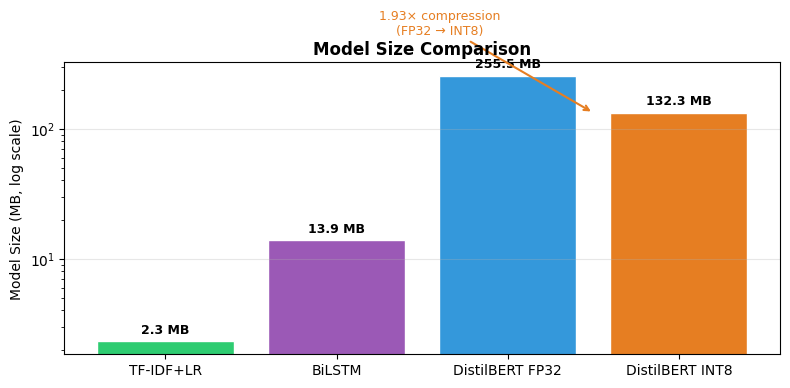

In [42]:
size_data={
    'Model':['TF-IDF+LR', 'BiLSTM', 'DistilBERT FP32', 'DistilBERT INT8'],
    'Size_MB':[RESULTS['logreg_sst2']['size_mb'], RESULTS['bilstm_sst2']['size_mb'],
                 RESULTS['bert_fp32_sst2']['size_mb'], RESULTS['bert_int8_sst2']['size_mb']],
}
size_df= pd.DataFrame(size_data)
fp32 =RESULTS['bert_fp32_sst2']['size_mb']
int8 =RESULTS['bert_int8_sst2']['size_mb']
print(f'DistilBERT FP32 :{fp32:.1f} MB')
print(f'DistilBERT INT8 :{int8:.1f} MB  →  {fp32/int8:.2f}× smaller')
print(f'BiLSTM : {RESULTS["bilstm_sst2"]["size_mb"]:.2f} MB')
print(f'TF-IDF + LR: {RESULTS["logreg_sst2"]["size_mb"]:.2f} MB')
fig, ax=plt.subplots(figsize=(8, 4))
bars=ax.bar(size_df['Model'], size_df['Size_MB'],color=pal4,edgecolor='white')
ax.set_yscale('log')
ax.set_ylabel('Model Size (MB, log scale)')
ax.set_title('Model Size Comparison',fontweight='bold')
ax.grid(axis='y', alpha=0.3)
for b, v in zip(bars,size_df['Size_MB']):
    ax.text(b.get_x()+b.get_width()/2, v*1.15, f'{v:.1f} MB',ha='center',fontsize=9,fontweight='bold')
ax.annotate(
    f'{fp32/int8:.2f}× compression\n(FP32 → INT8)',
    xy=(2.5,int8), xytext=(1.6,int8*4),
    fontsize=9,color='#E67E22',
    arrowprops=dict(arrowstyle='->',color='#E67E22',lw=1.5),
    ha='center',
)
plt.tight_layout()
plt.savefig(f'{FIG}/model_size_comparison.png',dpi=150,bbox_inches='tight')
plt.show()
size_df.to_csv(f'{RES}/model_size_reduction.csv',index=False)

##  BiLSTM efficiency comparison

BiLSTM sits in the middle of the accuracy speed spectrum.
Is it actually a good trade-off, or does DistilBERT INT8 make it redundant?

In [43]:
cmp= pd.DataFrame([
    {'Model': 'TF-IDF + LR',
     'Acc_SST2_%': RESULTS['logreg_sst2']['acc']*100,  'Acc_IMDb_%': RESULTS['logreg_imdb']['acc']*100,
     'Lat_SST2_ms': RESULTS['logreg_sst2']['lat_mean_ms'],'Lat_IMDb_ms': RESULTS['logreg_imdb']['lat_mean_ms'],
     'Size_MB': RESULTS['logreg_sst2']['size_mb']},
    {'Model': 'BiLSTM+GloVe+Attn',
     'Acc_SST2_%': RESULTS['bilstm_sst2']['acc']*100,'Acc_IMDb_%': RESULTS['bilstm_imdb']['acc']*100,
     'Lat_SST2_ms': RESULTS['bilstm_sst2']['lat_mean_ms'],'Lat_IMDb_ms': RESULTS['bilstm_imdb']['lat_mean_ms'],
     'Size_MB': RESULTS['bilstm_sst2']['size_mb']},
    {'Model': 'DistilBERT FP32',
     'Acc_SST2_%':RESULTS['bert_fp32_sst2']['acc']*100, 'Acc_IMDb_%': RESULTS['bert_fp32_imdb']['acc']*100,
     'Lat_SST2_ms':RESULTS['bert_fp32_sst2']['lat_mean_ms'], 'Lat_IMDb_ms': RESULTS['bert_fp32_imdb']['lat_mean_ms'],
     'Size_MB':RESULTS['bert_fp32_sst2']['size_mb']},
    {'Model': 'DistilBERT INT8',
     'Acc_SST2_%':RESULTS['bert_int8_sst2']['acc']*100,'Acc_IMDb_%': RESULTS['bert_int8_imdb']['acc']*100,
     'Lat_SST2_ms': RESULTS['bert_int8_sst2']['lat_mean_ms'],'Lat_IMDb_ms': RESULTS['bert_int8_imdb']['lat_mean_ms'],
     'Size_MB':RESULTS['bert_int8_sst2']['size_mb']},
])
print('Model Comparison:')
print(cmp.round(2).to_string(index=False))
cmp.to_csv(f'{RES}/bilstm_efficiency_comparison.csv',index=False)
print('Summary table generated and saved.')

Model Comparison:
            Model  Acc_SST2_%  Acc_IMDb_%  Lat_SST2_ms  Lat_IMDb_ms  Size_MB
      TF-IDF + LR       81.65       89.50         0.92         1.34     2.33
BiLSTM+GloVe+Attn       85.32       88.44         2.61         7.71    13.86
  DistilBERT FP32       90.71       91.07        49.94        99.25   255.50
  DistilBERT INT8       89.45       89.91        17.83        49.89   132.30
Summary table generated and saved.


### BiLSTM Efficiency Comparison - SST-2: Accuracy

In [44]:
pareto_rows= [
    {'Model': 'TF-IDF + LR',
     'Acc': RESULTS['logreg_sst2']['acc'], 'Lat_ms': RESULTS['logreg_sst2']['lat_mean_ms'],
     'Size_MB': RESULTS['logreg_sst2']['size_mb']},
    {'Model': 'BiLSTM+GloVe+Attn',
     'Acc': RESULTS['bilstm_sst2']['acc'],  'Lat_ms': RESULTS['bilstm_sst2']['lat_mean_ms'],
     'Size_MB': RESULTS['bilstm_sst2']['size_mb']},
    {'Model': 'DistilBERT FP32',
     'Acc': RESULTS['bert_fp32_sst2']['acc'], 'Lat_ms': RESULTS['bert_fp32_sst2']['lat_mean_ms'],
     'Size_MB': RESULTS['bert_fp32_sst2']['size_mb']},
    {'Model': 'DistilBERT INT8',
     'Acc': RESULTS['bert_int8_sst2']['acc'], 'Lat_ms': RESULTS['bert_int8_sst2']['lat_mean_ms'],
     'Size_MB': RESULTS['bert_int8_sst2']['size_mb']},
]
pareto_df=pd.DataFrame(pareto_rows)

def is_dominated(row,df):
    for _, other in df.iterrows():
        if other['Model'] == row['Model']: continue
        if (other['Acc'] >= row['Acc'] and other['Lat_ms'] <= row['Lat_ms'] and
            (other['Acc'] > row['Acc'] or other['Lat_ms'] < row['Lat_ms'])):
            return True
    return False

pareto_df['Dominated'] =pareto_df.apply(lambda r: is_dominated(r, pareto_df), axis=1)
pareto_df['On_Frontier']= ~pareto_df['Dominated']

print('Pareto Table (SST-2):')
print(pareto_df[['Model','Acc','Lat_ms','Size_MB','On_Frontier']].round(4).to_string(index=False))
pareto_df.to_csv(f'{RES}/pareto_frontier_sst2.csv',index=False)

Pareto Table (SST-2):
            Model    Acc  Lat_ms  Size_MB  On_Frontier
      TF-IDF + LR 0.8165   0.918     2.33         True
BiLSTM+GloVe+Attn 0.8532   2.612    13.86         True
  DistilBERT FP32 0.9071  49.940   255.50         True
  DistilBERT INT8 0.8945  17.830   132.30         True


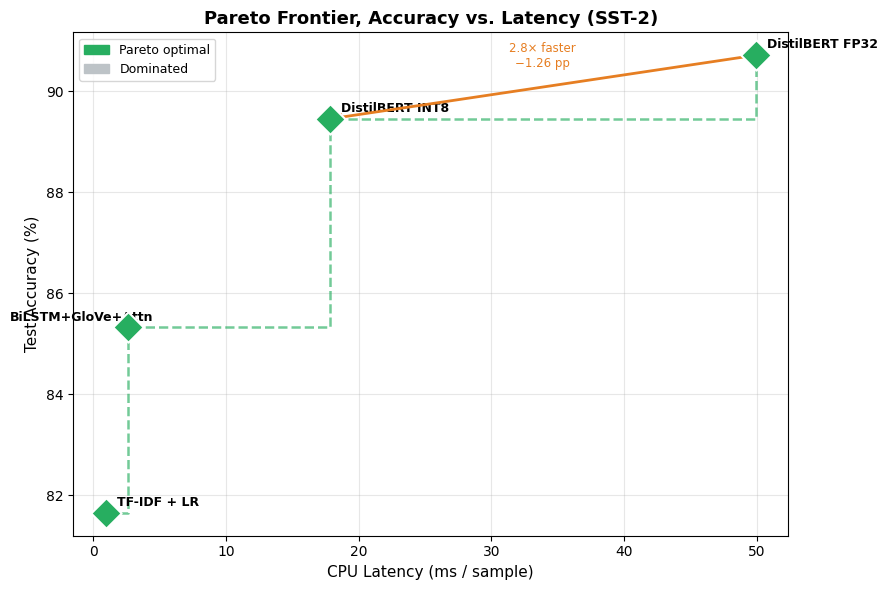

In [45]:
fig,ax=plt.subplots(figsize=(9,6))
for _,row in pareto_df.iterrows():
    c= '#27AE60' if row['On_Frontier'] else '#BDC3C7'
    m= 'D' if row['On_Frontier'] else 'o'
    s= 240 if row['On_Frontier'] else 120
    ax.scatter(row['Lat_ms'], row['Acc']*100, c=c, s=s, marker=m,
               zorder=5, edgecolors='white', linewidths=1.5)
    offset=(-85, 5) if 'BiLSTM' in row['Model'] else (8, 5)
    ax.annotate(row['Model'], (row['Lat_ms'], row['Acc']*100),
                textcoords='offset points', xytext=offset, fontsize=9,
                fontweight='bold' if row['On_Frontier'] else 'normal')
front= pareto_df[pareto_df['On_Frontier']].sort_values('Lat_ms')
ax.step(front['Lat_ms'],front['Acc']*100,
        where='post',color='#27AE60', lw=1.8,ls='--',alpha=0.65,label='Pareto frontier')
fp_lat=RESULTS['bert_fp32_sst2']['lat_mean_ms']
i8_lat= RESULTS['bert_int8_sst2']['lat_mean_ms']
fp_acc= RESULTS['bert_fp32_sst2']['acc']*100
i8_acc= RESULTS['bert_int8_sst2']['acc']*100
ax.annotate('',xy=(i8_lat, i8_acc),xytext=(fp_lat,fp_acc),
            arrowprops=dict(arrowstyle='->',color='#E67E22',lw=2))
ax.text((fp_lat+i8_lat)/2,(fp_acc+i8_acc)/2 +0.4,
        f'{fp_lat/i8_lat:.1f}× faster\n−{fp_acc-i8_acc:.2f} pp',
        ha='center', fontsize=8.5, color='#E67E22')

ax.set_xlabel('CPU Latency (ms / sample)',fontsize=11)
ax.set_ylabel('Test Accuracy (%)', fontsize=11)
ax.set_title('Pareto Frontier, Accuracy vs. Latency (SST-2)', fontweight='bold', fontsize=13)
ax.grid(True,alpha=0.3)

green_p= mpatches.Patch(color='#27AE60',label='Pareto optimal')
gray_p=mpatches.Patch(color='#BDC3C7',label='Dominated')
ax.legend(handles=[green_p, gray_p],fontsize=9)

plt.tight_layout()
plt.savefig(f'{FIG}/pareto_frontier.png', dpi=150,bbox_inches='tight')
plt.show()

##  Efficiency overview figure

### Efficiency Overview: Test Accuracy

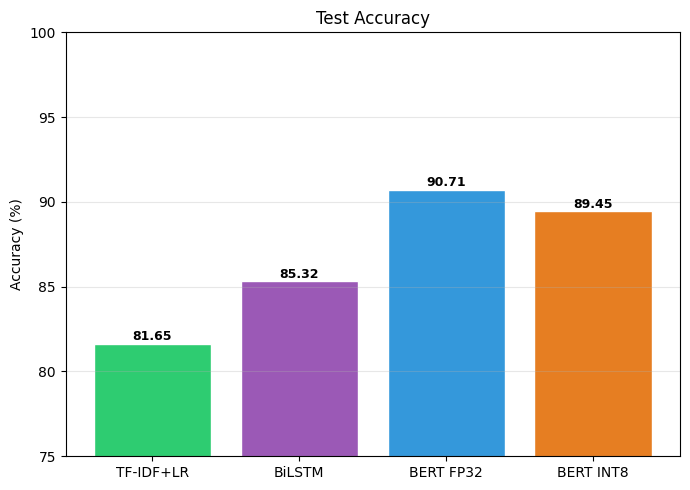

In [46]:
fig,ax=plt.subplots(figsize=(7,5))
bars=ax.bar(model_labels4,acc_vals4,color=pal4,edgecolor='white')
ax.set_ylim(75, 100);ax.set_ylabel('Accuracy (%)')
ax.set_title('Test Accuracy'); ax.grid(axis='y', alpha=0.3)
for b, v in zip(bars, acc_vals4):
    ax.text(b.get_x()+b.get_width() / 2,v+0.2, f'{v:.2f}',ha='center',fontsize=9,fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG}/efficiency_overview_accuracy.png',dpi=150,bbox_inches='tight')
plt.show()

### Efficiency Overview: CPU Latency

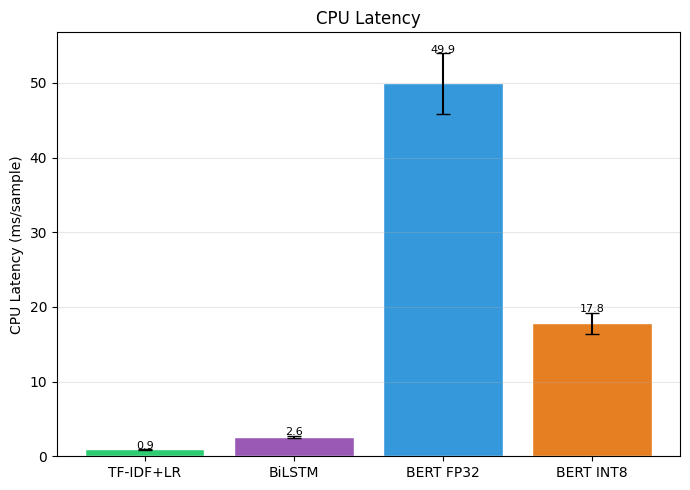

In [47]:
fig,ax=plt.subplots(figsize=(7, 5))
bars=ax.bar(model_labels4, lat_vals4,color=pal4,edgecolor='white',
                     yerr=std_vals4,capsize=5,error_kw=dict(color='#2C3E50',lw=1.5))
ax.set_ylabel('CPU Latency (ms/sample)');ax.set_title('CPU Latency')
ax.grid(axis='y',alpha=0.3)
for b,v in zip(bars,lat_vals4):
    ax.text(b.get_x() + b.get_width() / 2, v*1.08, f'{v:.1f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(f'{FIG}/efficiency_overview_latency.png',dpi=150,bbox_inches='tight')
plt.show()

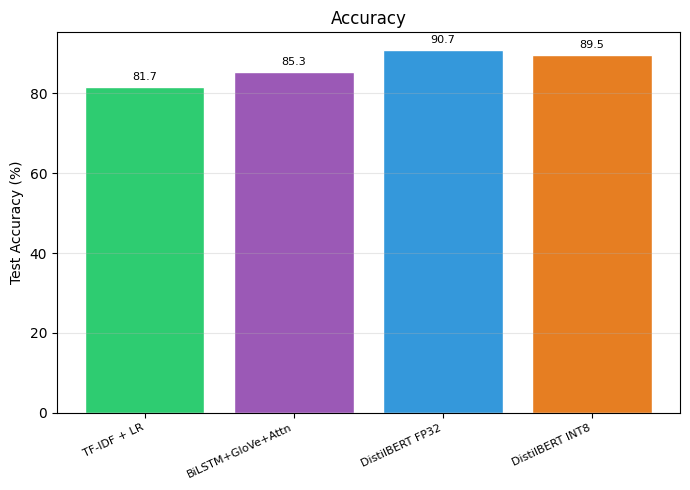

In [48]:
fig,ax=plt.subplots(figsize=(7, 5))
col='Acc_SST2_%'
ylabel='Test Accuracy (%)'
title='Accuracy'
bars=ax.bar(cmp['Model'],cmp[col], color=pal4, edgecolor='white')
ax.set_xticks(range(len(cmp['Model'])))
ax.set_xticklabels(cmp['Model'], rotation=25,ha='right',fontsize=8)
ax.set_title(title);ax.set_ylabel(ylabel)
ax.grid(axis='y',alpha=0.3)
for b, v in zip(bars,cmp[col]):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()*1.02,f'{v:.1f}', ha='center',fontsize=8)
plt.tight_layout()
plt.savefig(f'{FIG}/bilstm_efficiency_comparison_accuracy.png',dpi=150,bbox_inches='tight')
plt.show()

### Efficiency Overview: Pareto Frontier

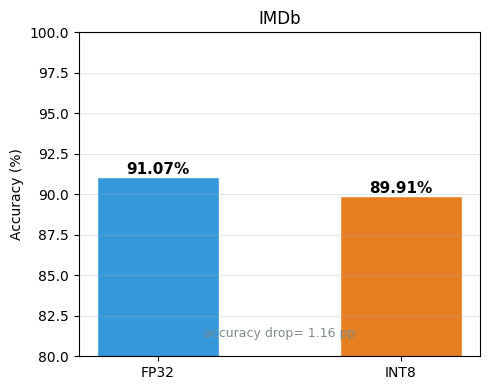

In [49]:
fig,ax=plt.subplots(figsize=(5,4))
ds= 'IMDb'
fp_k='bert_fp32_imdb'
it_k='bert_int8_imdb'
fp_acc =RESULTS[fp_k]['acc'] *100
it_acc =RESULTS[it_k]['acc']*100
bars = ax.bar(['FP32','INT8'],[fp_acc, it_acc],
              color=['#3498DB', '#E67E22'],edgecolor='white',width=0.5)
ax.set_ylim(80,100)
ax.set_title(ds)
ax.set_ylabel('Accuracy (%)')
ax.grid(axis='y',alpha=0.3)
for bar, val in zip(bars,[fp_acc, it_acc]):
    ax.text(bar.get_x() +bar.get_width()/2, val+0.2,
            f'{val:.2f}%',ha='center',fontsize=11,fontweight='bold')
ax.annotate(f'accuracy drop= {fp_acc - it_acc:.2f} pp',
            xy=(0.5,0.06), xycoords='axes fraction', ha='center',fontsize=9,color='#7F8C8D')
plt.tight_layout()
plt.savefig(f'{FIG}/quant_accuracy_comparison_imdb.png',dpi=150,bbox_inches='tight')
plt.show()

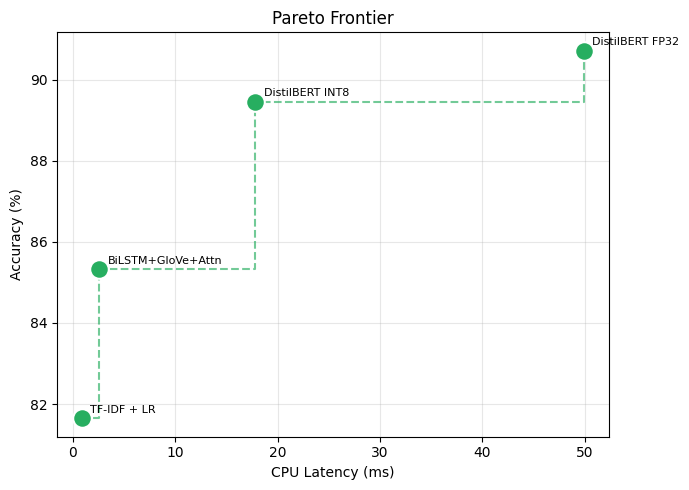

In [50]:
fig,ax=plt.subplots(figsize=(7,5))
for _,row in pareto_df.iterrows():
    c='#27AE60' if row['On_Frontier'] else '#BDC3C7'
    ax.scatter(row['Lat_ms'],row['Acc'] *100, c=c,s=180,zorder=5,
               edgecolors='white', linewidths=1.5)
    ax.annotate(row['Model'],(row['Lat_ms'], row['Acc'] * 100),
                textcoords='offset points', xytext=(6, 4), fontsize=8)
front=pareto_df[pareto_df['On_Frontier']].sort_values('Lat_ms')
ax.step(front['Lat_ms'], front['Acc']*100, where='post',
        color='#27AE60', lw=1.5, ls='--', alpha=0.65)
ax.set_xlabel('CPU Latency (ms)'); ax.set_ylabel('Accuracy (%)')
ax.set_title('Pareto Frontier'); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIG}/efficiency_overview_pareto.png', dpi=150, bbox_inches='tight')
plt.show()

### Efficiency Overview: Model Size

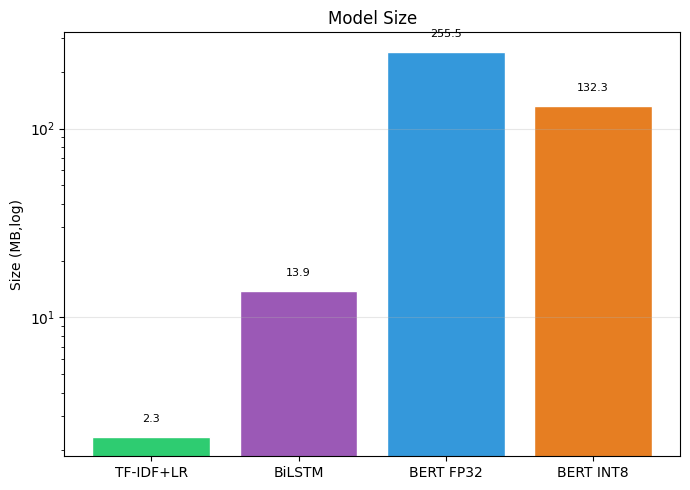

In [51]:
fig, ax=plt.subplots(figsize=(7,5))
bars =ax.bar(model_labels4, size_vals4,color=pal4,edgecolor='white')
ax.set_yscale('log'); ax.set_ylabel('Size (MB,log)')
ax.set_title('Model Size'); ax.grid(axis='y',alpha=0.3)
for b, v in zip(bars,size_vals4):
    ax.text(b.get_x()+b.get_width() /2,v *1.2, f'{v:.1f}',ha='center',fontsize=8)
plt.tight_layout()
plt.savefig(f'{FIG}/efficiency_overview_size.png',dpi=150,bbox_inches='tight')
plt.show()

### BiLSTM Efficiency Comparison - SST-2: Latency

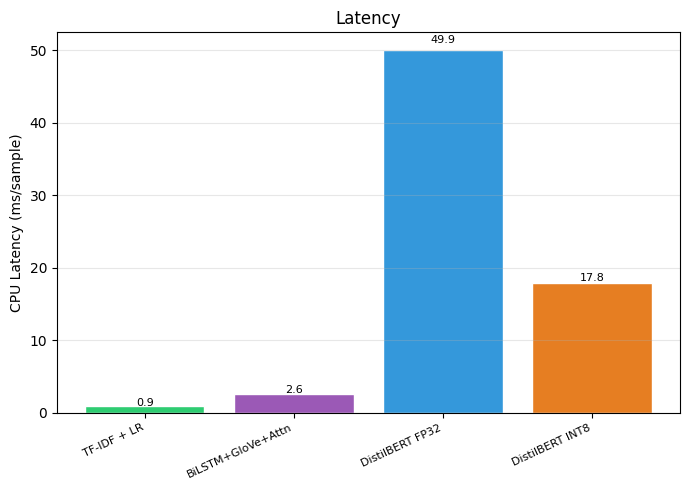

In [52]:
fig,ax=plt.subplots(figsize=(7,5))
col='Lat_SST2_ms'
ylabel='CPU Latency (ms/sample)'
title='Latency'
bars=ax.bar(cmp['Model'],cmp[col],color=pal4,edgecolor='white')
ax.set_xticks(range(len(cmp['Model'])))
ax.set_xticklabels(cmp['Model'], rotation=25, ha='right', fontsize=8)
ax.set_title(title); ax.set_ylabel(ylabel)
ax.grid(axis='y',alpha=0.3)
for b, v in zip(bars,cmp[col]):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()*1.02, f'{v:.1f}',ha='center',fontsize=8)

plt.tight_layout()
plt.savefig(f'{FIG}/bilstm_efficiency_comparison_latency.png',dpi=150,bbox_inches='tight')
plt.show()

### BiLSTM Efficiency Comparison - SST-2: Size

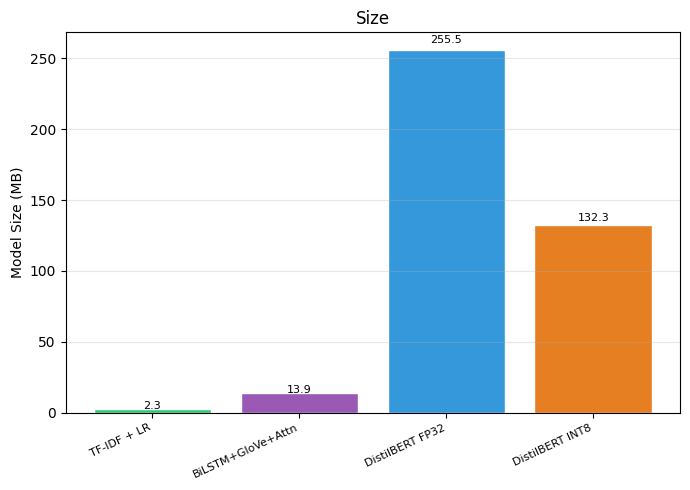

In [53]:
fig,ax =plt.subplots(figsize=(7, 5))
col ='Size_MB'
ylabel ='Model Size (MB)'
title= 'Size'
bars=ax.bar(cmp['Model'], cmp[col], color=pal4, edgecolor='white')
ax.set_xticks(range(len(cmp['Model'])))
ax.set_xticklabels(cmp['Model'],rotation=25,ha='right',fontsize=8)
ax.set_title(title); ax.set_ylabel(ylabel)
ax.grid(axis='y',alpha=0.3)
for b, v in zip(bars,cmp[col]):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()*1.02, f'{v:.1f}',ha='center',fontsize=8)
plt.tight_layout()
plt.savefig(f'{FIG}/bilstm_efficiency_comparison_size.png',dpi=150,bbox_inches='tight')
plt.show()

### Pareto Frontier Plot

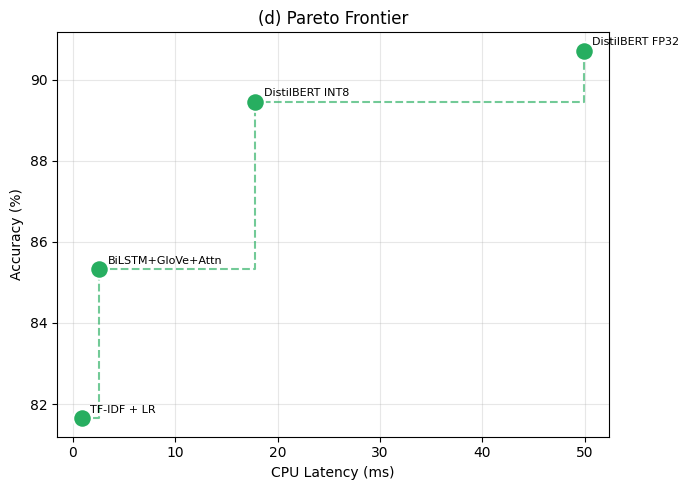

In [54]:
fig, ax=plt.subplots(figsize=(7, 5))
for _,row in pareto_df.iterrows():
    c = '#27AE60' if row['On_Frontier'] else '#BDC3C7'
    ax.scatter(row['Lat_ms'], row['Acc']*100, c=c,s=180,zorder=5,
               edgecolors='white', linewidths=1.5)
    ax.annotate(row['Model'], (row['Lat_ms'], row['Acc']*100),
                textcoords='offset points',xytext=(6,4), fontsize=8)
front= pareto_df[pareto_df['On_Frontier']].sort_values('Lat_ms')
ax.step(front['Lat_ms'], front['Acc']*100, where='post',
        color='#27AE60', lw=1.5, ls='--',alpha=0.65)
ax.set_xlabel('CPU Latency (ms)'); ax.set_ylabel('Accuracy (%)')
ax.set_title('(d) Pareto Frontier');ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIG}/efficiency_overview_pareto.png', dpi=150, bbox_inches='tight')
plt.show()

##  Full quantization summary table

In [55]:
summary=pd.DataFrame([
    {'Dataset':'SST-2','Precision':'FP32',
     'Acc_%':round(RESULTS['bert_fp32_sst2']['acc']*100,2),
     'F1': round(RESULTS['bert_fp32_sst2']['f1'],4),
     'Lat_mean_ms':RESULTS['bert_fp32_sst2']['lat_mean_ms'],
     'Lat_std_ms':RESULTS['bert_fp32_sst2']['lat_std_ms'],
     'Lat_p95_ms':round(p95('bert_fp32_sst2'),2),
     'Size_MB':RESULTS['bert_fp32_sst2']['size_mb'],
     'Speedup':'-', 'Compression':'-','Acc_drop_pp':'-'},
    {'Dataset':'SST-2','Precision':'INT8',
     'Acc_%': round(RESULTS['bert_int8_sst2']['acc']*100,2),
     'F1':round(RESULTS['bert_int8_sst2']['f1'],4),
     'Lat_mean_ms':RESULTS['bert_int8_sst2']['lat_mean_ms'],
     'Lat_std_ms':RESULTS['bert_int8_sst2']['lat_std_ms'],
     'Lat_p95_ms': round(p95('bert_int8_sst2'),2),
     'Size_MB': RESULTS['bert_int8_sst2']['size_mb'],
     'Speedup':  f"{RESULTS['bert_fp32_sst2']['lat_mean_ms']/RESULTS['bert_int8_sst2']['lat_mean_ms']:.2f}×",
     'Compression': f"{RESULTS['bert_fp32_sst2']['size_mb']/RESULTS['bert_int8_sst2']['size_mb']:.2f}×",
     'Acc_drop_pp': round((RESULTS['bert_fp32_sst2']['acc']-RESULTS['bert_int8_sst2']['acc'])*100,3)},
    {'Dataset':'IMDb','Precision':'FP32',
     'Acc_%': round(RESULTS['bert_fp32_imdb']['acc']*100,2),
     'F1':round(RESULTS['bert_fp32_imdb']['f1'],4),
     'Lat_mean_ms': RESULTS['bert_fp32_imdb']['lat_mean_ms'],
     'Lat_std_ms':RESULTS['bert_fp32_imdb']['lat_std_ms'],
     'Lat_p95_ms': round(p95('bert_fp32_imdb'),2),
     'Size_MB': RESULTS['bert_fp32_imdb']['size_mb'],
     'Speedup':'-','Compression':'-', 'Acc_drop_pp':'-'},
    {'Dataset':'IMDb','Precision':'INT8',
     'Acc_%': round(RESULTS['bert_int8_imdb']['acc']*100,2),
     'F1': round(RESULTS['bert_int8_imdb']['f1'],4),
     'Lat_mean_ms': RESULTS['bert_int8_imdb']['lat_mean_ms'],
     'Lat_std_ms':RESULTS['bert_int8_imdb']['lat_std_ms'],
     'Lat_p95_ms': round(p95('bert_int8_imdb'),2),
     'Size_MB': RESULTS['bert_int8_imdb']['size_mb'],
     'Speedup':  f"{RESULTS['bert_fp32_imdb']['lat_mean_ms']/RESULTS['bert_int8_imdb']['lat_mean_ms']:.2f}×",
     'Compression': f"{RESULTS['bert_fp32_imdb']['size_mb']/RESULTS['bert_int8_imdb']['size_mb']:.2f}×",
     'Acc_drop_pp': round((RESULTS['bert_fp32_imdb']['acc']-RESULTS['bert_int8_imdb']['acc'])*100,3)},
])

print('Quantization Summary:')
print(summary.to_string(index=False))
summary.to_csv(f'{RES}/quantization_summary.csv', index=False)
print(f'\nSaved to {RES}/quantization_summary.csv')

Quantization Summary:
Dataset Precision  Acc_%     F1  Lat_mean_ms  Lat_std_ms  Lat_p95_ms  Size_MB Speedup Compression Acc_drop_pp
  SST-2      FP32  90.71 0.9070        49.94        4.12       56.72    255.5       -           -           -
  SST-2      INT8  89.45 0.8941        17.83        1.40       20.13    132.3   2.80×       1.93×        1.26
   IMDb      FP32  91.07 0.9107        99.25        8.42      113.10    255.5       -           -           -
   IMDb      INT8  89.91 0.8990        49.89        5.92       59.63    132.3   1.99×       1.93×        1.16

Saved to /content/project_final/results/quantization_summary.csv


### Summary Table: All Models Performance

In [56]:
display(cmp.round(2).to_string(index=False))

'            Model  Acc_SST2_%  Acc_IMDb_%  Lat_SST2_ms  Lat_IMDb_ms  Size_MB\n      TF-IDF + LR       81.65       89.50         0.92         1.34     2.33\nBiLSTM+GloVe+Attn       85.32       88.44         2.61         7.71    13.86\n  DistilBERT FP32       90.71       91.07        49.94        99.25   255.50\n  DistilBERT INT8       89.45       89.91        17.83        49.89   132.30'

## Summary

| Finding | Numbers |
|---|---|
| INT8 accuracy drop | −1.26 pp (SST-2), −1.16 pp (IMDb) |
| INT8 latency speedup | **2.80×** (SST-2), **1.99×** (IMDb) |
| INT8 model compression | **1.93×** — 255 MB → 132 MB |
| p95 latency, BERT INT8 SST-2 | **20.13 ms** |
| Pareto result | BiLSTM is dominated on SST-2: DistilBERT INT8 is 2.9× faster on IMDb and 5.3 pp more accurate |
| Best deployment choice | DistilBERT INT8 — top accuracy at 1.93× smaller footprint and 2.8× faster |

### Deliverables
| File | Description |
|---|---|
| `figures/quant_accuracy_comparison.png` | Accuracy before/after INT8 |
| `figures/latency_benchmarks.png` | Mean, p95, log-scale |
| `figures/memory_footprint.png` | Disk size + estimated RSS |
| `figures/model_size_comparison.png` | Size on disk with compression annotation |
| `figures/bilstm_efficiency_comparison.png` | 3-way comparison |
| `figures/pareto_frontier.png` | Pareto plot with speedup annotation |
| `figures/efficiency_overview.png` | 2×2 report figure |
| `results/quantization_summary.csv` | Full quant table |
| `results/latency_benchmarks.csv` | All latency numbers |
| `results/pareto_frontier_sst2.csv` | Pareto domination table |